In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

print("Project Root:", project_root)

Project Root: c:\Users\dpati\OneDrive\Desktop\AI_NET


In [2]:
from src.models.train import ModelTrainer
from src.features.feature_engineering import FeatureEngineer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [3]:
trainer = ModelTrainer()

trainer.prepare_data()

trainer.train()

Encoder saved to: C:\Users\dpati\OneDrive\Desktop\AI_NET\saved_models\encoder.pkl
Data preprocessing completed successfully.
Random Forest training completed.


In [4]:
engineer = FeatureEngineer(trainer.model)

importance_df = engineer.calculate_feature_importance(
    trainer.X_train
)

importance_df.head(10)

,Feature,Importance
0,sttl,0.102879
1,ct_state_ttl,0.078431
2,dload,0.056260
3,rate,0.048063
4,dttl,0.044816
5,sload,0.042788
6,synack,0.034581
7,ct_srv_dst,0.032213
8,sbytes,0.032061
9,tcprtt,0.031915


In [5]:
selected = engineer.select_features()

print("Number of Selected Features:", len(selected))

print(selected[:10])

Selected 28 features.
Number of Selected Features: 28
['sttl', 'ct_state_ttl', 'dload', 'rate', 'dttl', 'sload', 'synack', 'ct_srv_dst', 'sbytes', 'tcprtt']


In [6]:
trainer.X_train.shape

(175341, 194)

In [7]:
X_train_selected = trainer.X_train[engineer.selected_features]

In [8]:
X_train_selected = engineer.transform(
    trainer.X_train
)

X_test_selected = engineer.transform(
    trainer.X_test
)

print("Original Shape :", trainer.X_train.shape)
print("New Shape      :", X_train_selected.shape)

Original Shape : (175341, 194)
New Shape      : (175341, 28)


In [9]:
rf_selected = RandomForestClassifier(
    random_state=42
)

rf_selected.fit(
    X_train_selected,
    trainer.y_train
)

print("Training Completed!")

Training Completed!


In [10]:
predictions = rf_selected.predict(
    X_test_selected
)

In [11]:
accuracy = accuracy_score(
    trainer.y_test,
    predictions
)

precision = precision_score(
    trainer.y_test,
    predictions
)

recall = recall_score(
    trainer.y_test,
    predictions
)

f1 = f1_score(
    trainer.y_test,
    predictions
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8693
Precision: 0.8168
Recall   : 0.9831
F1 Score : 0.8923


In [12]:
print(classification_report(
    trainer.y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.97      0.73      0.83     37000
           1       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332



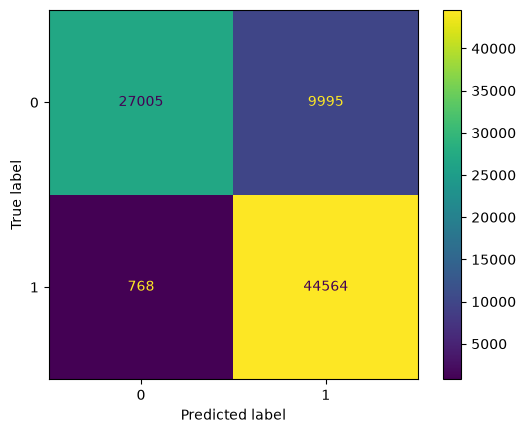

In [13]:
cm = confusion_matrix(
    trainer.y_test,
    predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

display.plot()

plt.show()